In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import random
import tqdm
import os
from collections import deque

In [4]:
def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None


In [5]:
SCENARIO_IDS = list(range(1, 51))  
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

WINDOW_SIZE = 5      
STEP = 1             
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 30
HIDDEN1 = 128
HIDDEN2 = 64
DROPOUT = 0.3
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


In [8]:
class WindowedScenarioDataset(Dataset):
    def __init__(self, df_list, window_size=5, step=1):
        self.window_size = window_size
        self.step = step
        self.X = []
        self.y = []
        for df in df_list:
            arr = df.drop(columns=["Leaks"]).values.astype(np.float32)  
            labs = df["Leaks"].values.astype(np.int64)                
            T, F = arr.shape
            for start in range(0, T - window_size + 1, step):
                window = arr[start:start+window_size].reshape(-1)     
                target = labs[start + window_size - 1]            
                self.X.append(window)
                self.y.append(target)
        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
class LeakANN(nn.Module):
    def __init__(self, input_dim, hidden1=128, hidden2=64, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = torch.sigmoid(x).squeeze(1)
        return x

In [10]:
def compute_global_mean_std(df_list):
    sum_ = None
    sumsq_ = None
    n_total = 0
    for df in df_list:
        arr = df.drop(columns=["Leaks"]).values.astype(np.float64)
        if sum_ is None:
            sum_ = arr.sum(axis=0)
            sumsq_ = (arr**2).sum(axis=0)
        else:
            sum_ += arr.sum(axis=0)
            sumsq_ += (arr**2).sum(axis=0)
        n_total += arr.shape[0]
    mean = sum_ / n_total
    var = (sumsq_ / n_total) - (mean**2)
    std = np.sqrt(np.maximum(var, 1e-6))
    return mean.astype(np.float32), std.astype(np.float32)

def normalize_df(df, mean, std):
    cols = [c for c in df.columns if c != "Leaks"]
    df2 = df.copy()
    df2[cols] = (df2[cols] - mean) / std
    return df2

In [11]:
def main():
    all_dfs = []
    valid_ids = []
    missing = []
    print("Loading scenarios and applying aggregation...")
    for sid in tqdm.tqdm(SCENARIO_IDS):
        try:
            df = load_scenario_data(sid) 
            if df is None or len(df) == 0:
                missing.append(sid)
                continue
            if "Timestamps" in df.columns:
                df = df.drop(columns=["Timestamps"])
            if "Leaks" not in df.columns:
                raise ValueError(f"scenario {sid} missing 'Leaks' column")
            df_agg = aggregate_nonleak_rows(df, leak_col="Leaks")
            df_agg = df_agg.reset_index(drop=True)
            all_dfs.append(df_agg)
            valid_ids.append(sid)
        except Exception as e:
            print(f"Skipping scenario {sid}: {repr(e)}")
            missing.append(sid)
            continue
    print(f"Loaded {len(all_dfs)} scenarios; skipped {len(missing)} scenarios.")

    N = len(all_dfs)
    idxs = list(range(N))
    random.shuffle(idxs)
    n_train = int(N * TRAIN_RATIO)
    n_val = int(N * VAL_RATIO)
    train_idx = idxs[:n_train]
    val_idx = idxs[n_train:n_train + n_val]
    test_idx = idxs[n_train + n_val:]
    train_dfs = [all_dfs[i] for i in train_idx]
    val_dfs = [all_dfs[i] for i in val_idx]
    test_dfs = [all_dfs[i] for i in test_idx]
    print(f"Split: train={len(train_dfs)}, val={len(val_dfs)}, test={len(test_dfs)}")

    mean, std = compute_global_mean_std(train_dfs)
    
    np.savetxt("mean.txt", mean)
    np.savetxt("std.txt", std)
    
    train_dfs = [normalize_df(df, mean, std) for df in train_dfs]
    val_dfs = [normalize_df(df, mean, std) for df in val_dfs]
    test_dfs = [normalize_df(df, mean, std) for df in test_dfs]

    train_ds = WindowedScenarioDataset(train_dfs, window_size=WINDOW_SIZE, step=STEP)
    val_ds = WindowedScenarioDataset(val_dfs, window_size=WINDOW_SIZE, step=STEP)
    test_ds = WindowedScenarioDataset(test_dfs, window_size=WINDOW_SIZE, step=STEP)
    print("Dataset sizes (windows):", len(train_ds), len(val_ds), len(test_ds))

    input_dim = train_ds.X.shape[1] 
    unique, counts = np.unique(train_ds.y, return_counts=True)
    counts_map = dict(zip(unique, counts))
    n_pos = counts_map.get(1, 0)
    n_neg = counts_map.get(0, 0)
    print("Train class counts:", counts_map)
    weight_for_0 = 1.0 if n_neg == 0 else (n_pos + n_neg) / (2.0 * n_neg)
    weight_for_1 = 1.0 if n_pos == 0 else (n_pos + n_neg) / (2.0 * n_pos)
    pos_weight = torch.tensor(weight_for_1 / weight_for_0).to(DEVICE) 
    print(f"Class weights (approx): neg={weight_for_0:.3f}, pos={weight_for_1:.3f}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = LeakANN(input_dim, hidden1=HIDDEN1, hidden2=HIDDEN2, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
  
    def bce_weighted(preds, targets):
        eps = 1e-7
        preds = torch.clamp(preds, eps, 1 - eps)
        weights = torch.where(targets == 1, torch.tensor(weight_for_1, device=DEVICE), torch.tensor(weight_for_0, device=DEVICE))
        loss = - (weights * (targets.float() * torch.log(preds) + (1 - targets.float()) * torch.log(1 - preds)))
        return loss.mean()

    best_val_f1 = -1.0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            preds = model(xb)          
            loss = bce_weighted(preds, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_ds)
        history["train_loss"].append(train_loss)

        model.eval()
        val_loss = 0.0
        preds_all = []
        labs_all = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                preds = model(xb)
                loss = bce_weighted(preds, yb)
                val_loss += loss.item() * xb.size(0)
                preds_all.append(preds.cpu().numpy())
                labs_all.append(yb.cpu().numpy())
        val_loss = val_loss / len(val_ds)
        preds_all = np.concatenate(preds_all)
        labs_all = np.concatenate(labs_all)
        pred_labels = (preds_all >= 0.5).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average='binary', zero_division=0)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(f1)

        print(f"Epoch {epoch}/{EPOCHS} - train_loss: {train_loss:.6f}  val_loss: {val_loss:.6f}  val_f1: {f1:.4f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            torch.save(model.state_dict(), "best_leak_ann.pth")
    print("Training finished. Best val F1:", best_val_f1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(history["val_f1"], label="val_f1")
    plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend()
    plt.title("Validation F1")
    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()

    model.load_state_dict(torch.load("best_leak_ann.pth"))
    model.eval()
    preds_all = []
    labs_all = []
    with torch.no_grad():
        for xb, yb in tqdm.tqdm(test_loader):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            preds = model(xb)
            preds_all.append(preds.cpu().numpy())
            labs_all.append(yb.cpu().numpy())
    preds_all = np.concatenate(preds_all)
    labs_all = np.concatenate(labs_all)
    pred_labels = (preds_all >= 0.5).astype(int)
    acc = accuracy_score(labs_all, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average='binary', zero_division=0)
    cm = confusion_matrix(labs_all, pred_labels)
    print("Test metrics: acc = {:.4f}, precision = {:.4f}, recall = {:.4f}, f1 = {:.4f}".format(acc, p, r, f1))
    print("Confusion matrix:\n", cm)

    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion matrix (test)")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.savefig("confusion_matrix_test.png")
    plt.show()

Loading scenarios and applying aggregation...


100%|██████████| 50/50 [12:27<00:00, 14.95s/it]


Loaded 50 scenarios; skipped 0 scenarios.
Split: train=40, val=5, test=5
Dataset sizes (windows): 332516 61326 50382
Train class counts: {0: 183970, 1: 148546}
Class weights (approx): neg=0.904, pos=1.119
Epoch 1/30 - train_loss: 0.080218  val_loss: 0.386128  val_f1: 0.9220
Epoch 2/30 - train_loss: 0.027812  val_loss: 0.331369  val_f1: 0.9433
Epoch 3/30 - train_loss: 0.024056  val_loss: 0.348402  val_f1: 0.9440
Epoch 4/30 - train_loss: 0.020414  val_loss: 0.364704  val_f1: 0.9427
Epoch 5/30 - train_loss: 0.019185  val_loss: 0.250536  val_f1: 0.9618
Epoch 6/30 - train_loss: 0.017141  val_loss: 0.292152  val_f1: 0.9510
Epoch 7/30 - train_loss: 0.016462  val_loss: 0.294561  val_f1: 0.9542
Epoch 8/30 - train_loss: 0.016302  val_loss: 0.220235  val_f1: 0.9681
Epoch 9/30 - train_loss: 0.014781  val_loss: 0.258118  val_f1: 0.9629
Epoch 10/30 - train_loss: 0.014494  val_loss: 0.228822  val_f1: 0.9654
Epoch 11/30 - train_loss: 0.014588  val_loss: 0.220098  val_f1: 0.9716
Epoch 12/30 - train_los

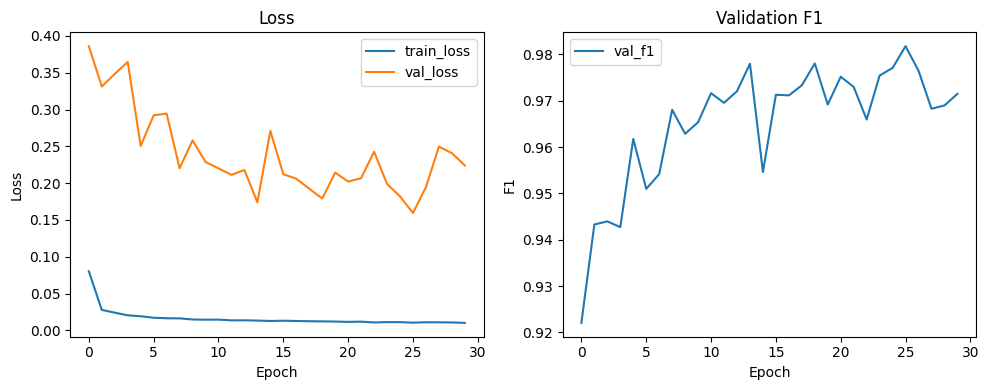

100%|██████████| 99/99 [00:00<00:00, 160.75it/s]


Test metrics: acc = 0.9887, precision = 0.9960, recall = 0.9860, f1 = 0.9910
Confusion matrix:
 [[18462   126]
 [  444 31350]]


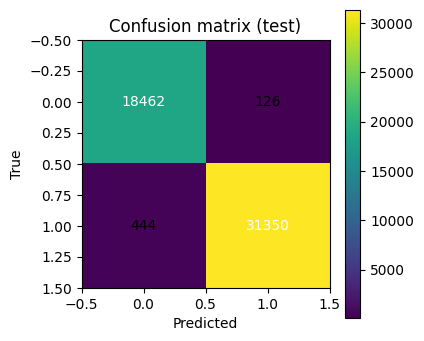

In [20]:
main()

In [2]:
import os 
dir = os.getcwd()
leakdb = os.path.join(dir, "..")
text = os.path.join(leakdb, "txt")


In [11]:
def test_unseen_scenario(
   id,
   model_path = os.path.join(leakdb, "best_leak_ann.pth"),
   base_path = r"D:\LeakDB_full_data\Hanoi",
   mean=None,
   std=None,
   window_size=5,
   step=1,
   hidden1=128,
   hidden2=64,
   dropout=0.3,
   device=None 
):
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    df = load_scenario_data(id, base_path)
    
    if df is None:
        print(f"Scenario-{id} could not be loaded.")
        return None
    
    if "Timestamps" in df.columns:
        df = df.drop(columns=["Timestamps"])
        
    df = aggregate_nonleak_rows(df, leak_col="Leaks").reset_index(drop=True)
    
    if mean is None or std is None:
        raise ValueError("mean and std must be provided from training data.")
    
    df_norm = normalize_df(df, mean, std)
    
    unseen_ds = WindowedScenarioDataset([df_norm], window_size=window_size, step=step)
    unseen_loader = torch.utils.data.DataLoader(unseen_ds, batch_size=512, shuffle=False)
    
    input_dim = unseen_ds.X.shape[1]
    model = LeakANN(input_dim, hidden1=hidden1, hidden2=hidden2, dropout=dropout)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    preds_all, labs_all = [], []
    
    with torch.no_grad():
        for xb, yb in unseen_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            preds_all.append(preds.cpu().numpy())
            labs_all.append(yb.cpu().numpy())
            
    preds_all = np.concatenate(preds_all)
    labs_all = np.concatenate(labs_all)
    pred_labels = (preds_all >= 0.5).astype(int)
    
    acc = accuracy_score(labs_all, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average="binary", zero_division=0)
    cm = confusion_matrix(labs_all, pred_labels)
    
    print(f"\nScenario {id} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall:    {r:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix - Scenario {id}")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.show()
    
    return {
        "scenario_id": id,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "confusion_matrix": cm
    }

In [3]:
model = os.path.join(leakdb, "best_leak_ann.pth")


Scenario 100 Results:
Accuracy:  0.9748
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
Confusion Matrix:
 [[5689  147]
 [   0    0]]


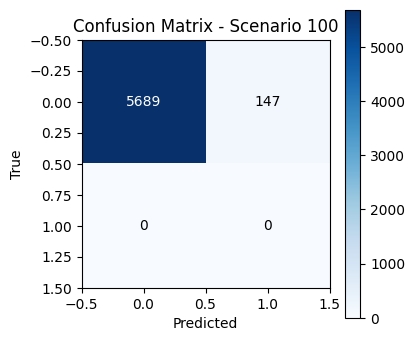

{'scenario_id': 100,
 'accuracy': 0.9748115147361206,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'confusion_matrix': array([[5689,  147],
        [   0,    0]], dtype=int64)}

In [12]:
mean = np.loadtxt(os.path.join(text, "mean.txt"))
std = np.loadtxt(os.path.join(text, "std.txt"))

results = test_unseen_scenario(100, model_path=model, base_path=r"D:\LeakDB_full_data\Hanoi", mean=mean, std=std)
results


Scenario 60 Results:
Accuracy:  0.8818
Precision: 0.9993
Recall:    0.6256
F1 Score:  0.7695
Confusion Matrix:
 [[5059    1]
 [ 873 1459]]


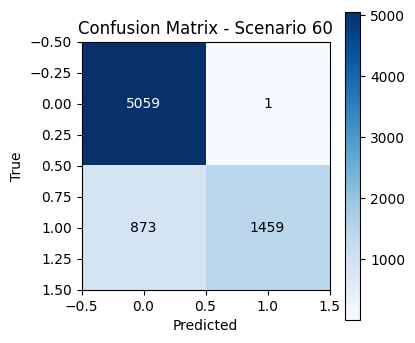

In [13]:
results = test_unseen_scenario(60, model_path=model, base_path=r"D:\LeakDB_full_data\Hanoi", mean=mean, std=std)


Scenario 55 Results:
Accuracy:  0.9993
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
Confusion Matrix:
 [[5832    4]
 [   0    0]]


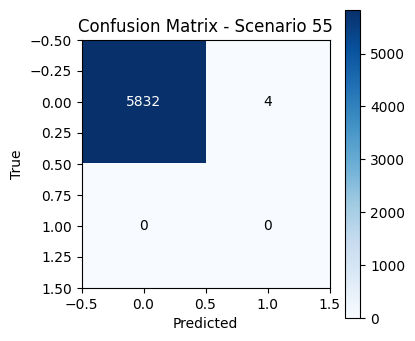

In [14]:
results = test_unseen_scenario(55, model_path=model, base_path=r"D:\LeakDB_full_data\Hanoi", mean=mean, std=std)


Scenario 52 Results:
Accuracy:  0.9888
Precision: 0.9952
Recall:    0.9667
F1 Score:  0.9807
Confusion Matrix:
 [[5117   10]
 [  71 2060]]


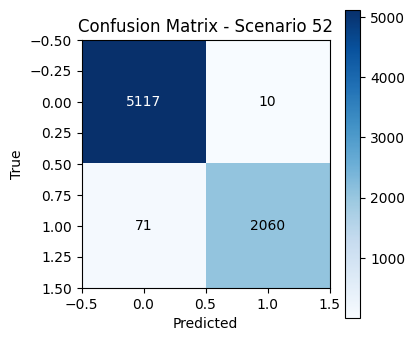

In [15]:
results = test_unseen_scenario(52, model_path=model, base_path=r"D:\LeakDB_full_data\Hanoi", mean=mean, std=std)


Scenario 54 Results:
Accuracy:  0.9478
Precision: 0.9999
Recall:    0.9441
F1 Score:  0.9712
Confusion Matrix:
 [[ 1021     1]
 [  807 13641]]


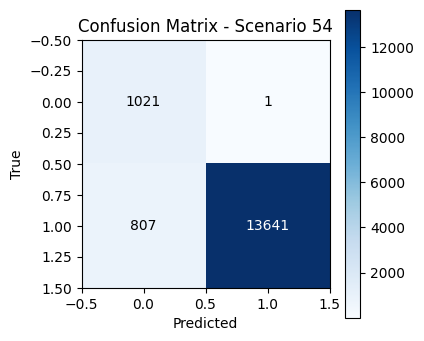

In [ ]:

results = test_unseen_scenario(54, model_path=model, base_path=r"D:\LeakDB_full_data\Hanoi", mean=mean, std=std)

In [13]:
df_54 = load_scenario_data(54, base_path=r"D:\LeakDB_full_data\Hanoi")
df_54["Leaks"].value_counts()

Leaks
1    14448
0     3072
Name: count, dtype: int64

In [14]:
df_54_compressed = aggregate_nonleak_rows(df_54, "Leaks")
df_54_compressed.head(5)

,demand_node_1,demand_node_2,demand_node_3,demand_node_4,demand_node_5,demand_node_6,demand_node_7,demand_node_8,demand_node_9,demand_node_10,...,flow_link_26,flow_link_27,flow_link_28,flow_link_29,flow_link_30,flow_link_31,flow_link_32,flow_link_33,flow_link_34,Leaks
0,-2989.2,84.0,76.8,80.4,133.2,96.0,38.4,55.2,141.6,172.8,...,-48.0,64.8,183.6,1138.8,1033.2,885.6,650.4,574.8,500.4,0
1,-2287.2,72.0,61.2,56.4,97.2,82.8,26.4,37.2,111.6,118.8,...,-37.2,48.0,144.0,873.6,793.2,688.8,493.2,439.2,387.6,0
2,-2317.2,66.0,60.0,58.8,92.4,72.0,27.6,38.4,112.8,126.0,...,-38.4,50.4,142.8,867.6,782.4,678.0,487.2,434.4,378.0,0
3,-3236.4,88.8,81.6,87.6,142.8,102.0,40.8,51.6,151.2,198.0,...,-52.8,72.0,193.2,1226.4,1113.6,957.6,699.6,619.2,535.2,0
4,-4687.2,127.2,114.0,134.4,224.4,135.6,67.2,70.8,204.0,325.2,...,-74.4,98.4,288.0,1780.8,1605.6,1374.0,1051.2,920.4,795.6,0


In [15]:
df_54_compressed.shape

(15474, 99)

In [16]:
df_54_compressed["Leaks"].value_counts()

Leaks
1    14448
0     1026
Name: count, dtype: int64